# 02 - 聚类与拓扑验证 (Clustering & Topological Validation)

目标：
1. 基于 PCA 构建 KNN 图，UMAP 可视化
2. Leiden 图聚类，识别细胞亚群
3. **核心创新**：对 PCA 嵌入计算持久同调，验证聚类结构的拓扑稳定性
4. 对比：哪些 Leiden 簇在拓扑上表现为独立的"连通分支"

## 1. 加载 Phase 1 预处理后的数据

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor="white")

from src import config
from src.io import load_h5ad
from src.clustering import run_neighbors, run_umap, run_leiden
from src.topology import compute_persistence, plot_persistence_diagrams, extract_topological_stats

In [2]:
# 加载数据
adata = load_h5ad("pbmc3k_qc_normalized.h5ad")
print(f"加载数据: {adata.n_obs} 细胞 × {adata.n_vars} 基因")

加载数据: 2638 细胞 × 2000 基因


## 2. 构建邻居图 + UMAP 降维

In [3]:
# 使用 PCA 前 30 个主成分构建 KNN 图
run_neighbors(adata, n_pcs=config.N_PCS_CLUSTERING, n_neighbors=config.NEIGHBORS_N)
run_umap(adata)

print("UMAP 坐标已计算，存储在 adata.obsm['X_umap']")

computing neighbors
    using 'X_pca' with n_pcs = 30


d:\miniconda3\envs\rna\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:43)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:05)
UMAP 坐标已计算，存储在 adata.obsm['X_umap']


## 3. Leiden 聚类

In [4]:
run_leiden(adata, resolution=config.LEIDEN_RESOLUTION)

n_clusters = adata.obs["leiden"].nunique()
print(f"Leiden 聚类完成，共 {n_clusters} 个簇")

running Leiden clustering


e:\project\scRNA-topo-pipeline\notebook\..\src\clustering.py:30: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=resolution, key_added=key_added)


    finished: found 6 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)
Leiden 聚类完成，共 6 个簇


In [5]:
# 查看每个簇的细胞数
print("\n各簇细胞数:")
print(adata.obs["leiden"].value_counts().sort_index())


各簇细胞数:
leiden
0    1181
1     639
2     427
3     342
4      36
5      13
Name: count, dtype: int64


## 4. UMAP 可视化（按聚类着色）

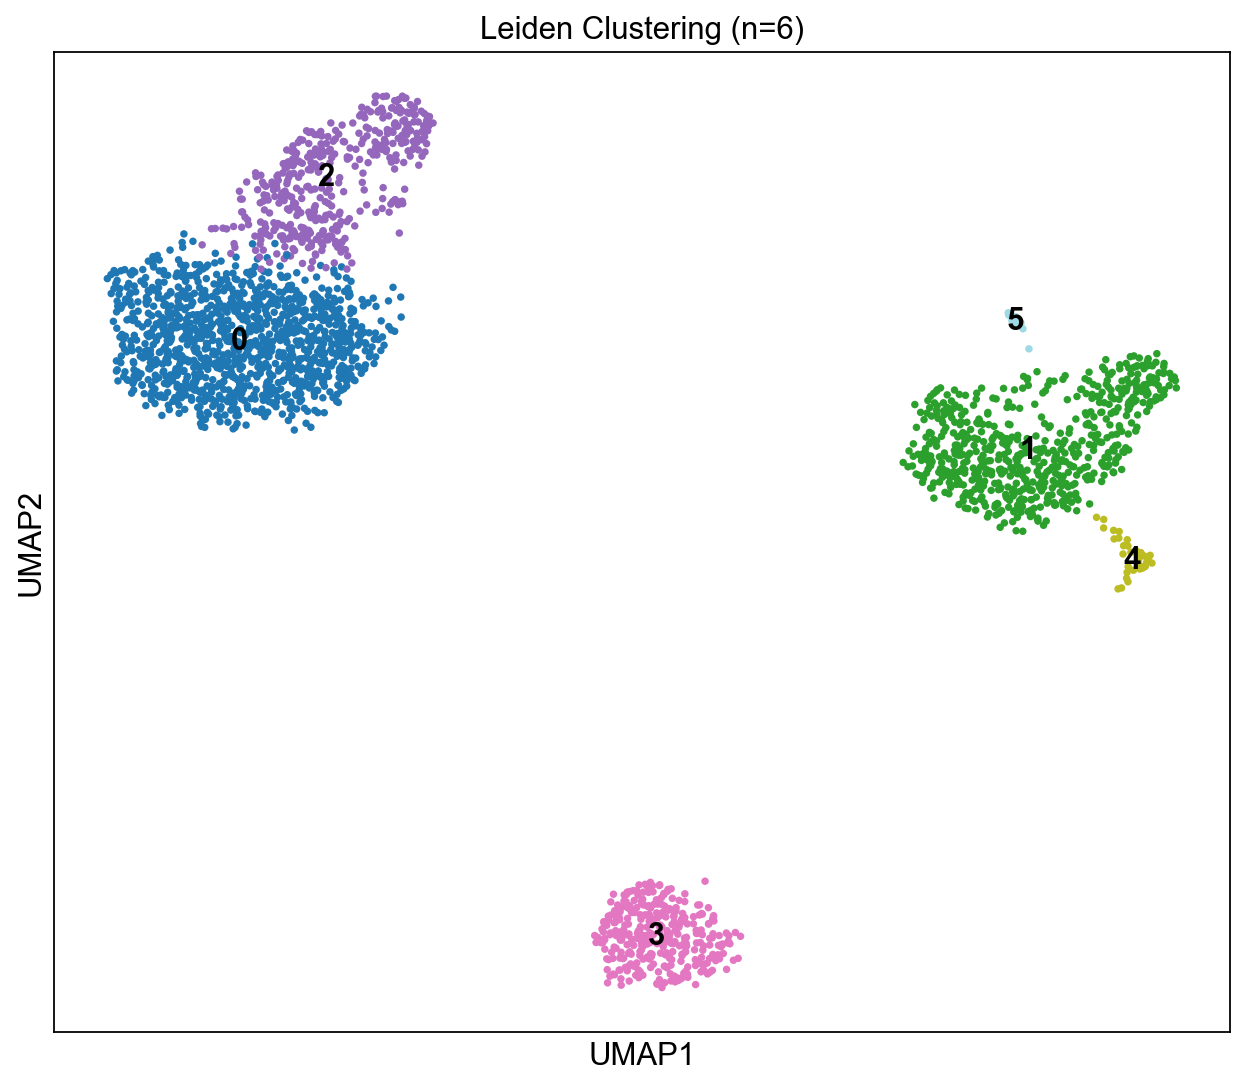

In [6]:
fig, ax = plt.subplots(figsize=(8, 7))
sc.pl.umap(adata, color="leiden", ax=ax, show=False, legend_loc="on data",
           palette="tab20", title=f"Leiden Clustering (n={n_clusters})")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "02_umap_leiden.png", dpi=150, bbox_inches="tight")
plt.show()

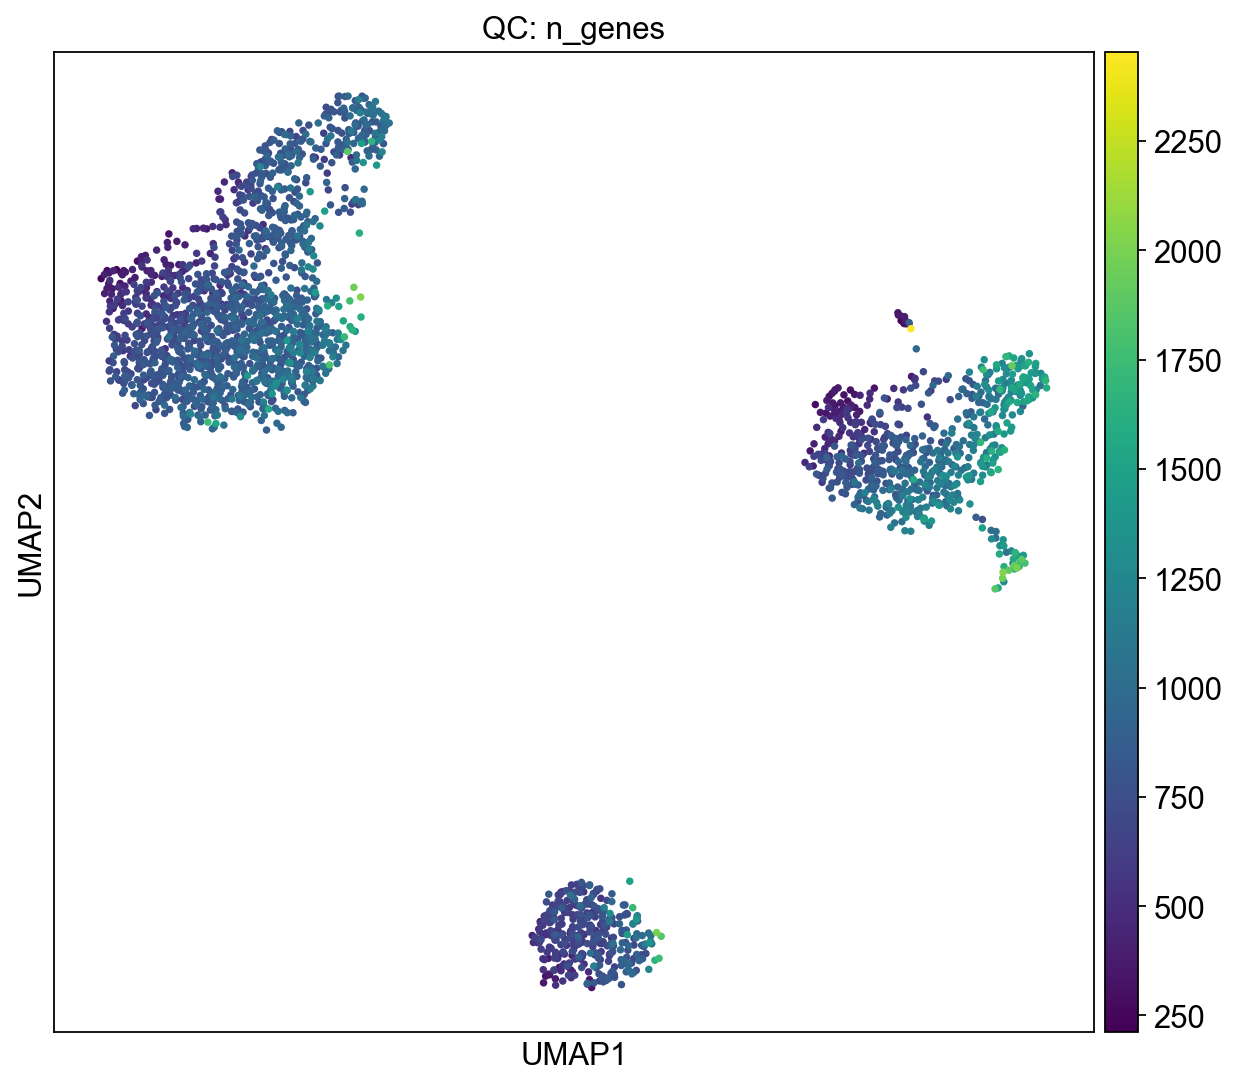

In [7]:
# 同时查看 n_genes 分布（验证无批次偏差）
fig, ax = plt.subplots(figsize=(8, 7))
sc.pl.umap(adata, color="n_genes_by_counts", ax=ax, show=False, 
           title="QC: n_genes")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "02_umap_qc.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. 拓扑验证 —— 全量数据的持久同调

将细胞的 PCA 嵌入（前 10 维）视为高维点云，计算 Rips 复形的持久同调。
关键问题：Leiden 识别的 n 个簇，是否在拓扑上对应 n 个独立的连通分支？

In [8]:
# 提取用于拓扑分析的 PCA 坐标（前 10 维，降低计算量）
pca_topo = adata.obsm["X_pca"][:, :config.TOPO_PCS]
print(f"拓扑分析点云: {pca_topo.shape} (2638 细胞 × 10 PC)")

# 计算持久同调（约需 10-30 秒，取决于机器）
print("正在计算持久同调 (ripser)...")
result_full = compute_persistence(pca_topo, maxdim=config.TOPO_MAXDIM)
print("计算完成")

拓扑分析点云: (2638, 10) (2638 细胞 × 10 PC)
正在计算持久同调 (ripser)...
计算完成


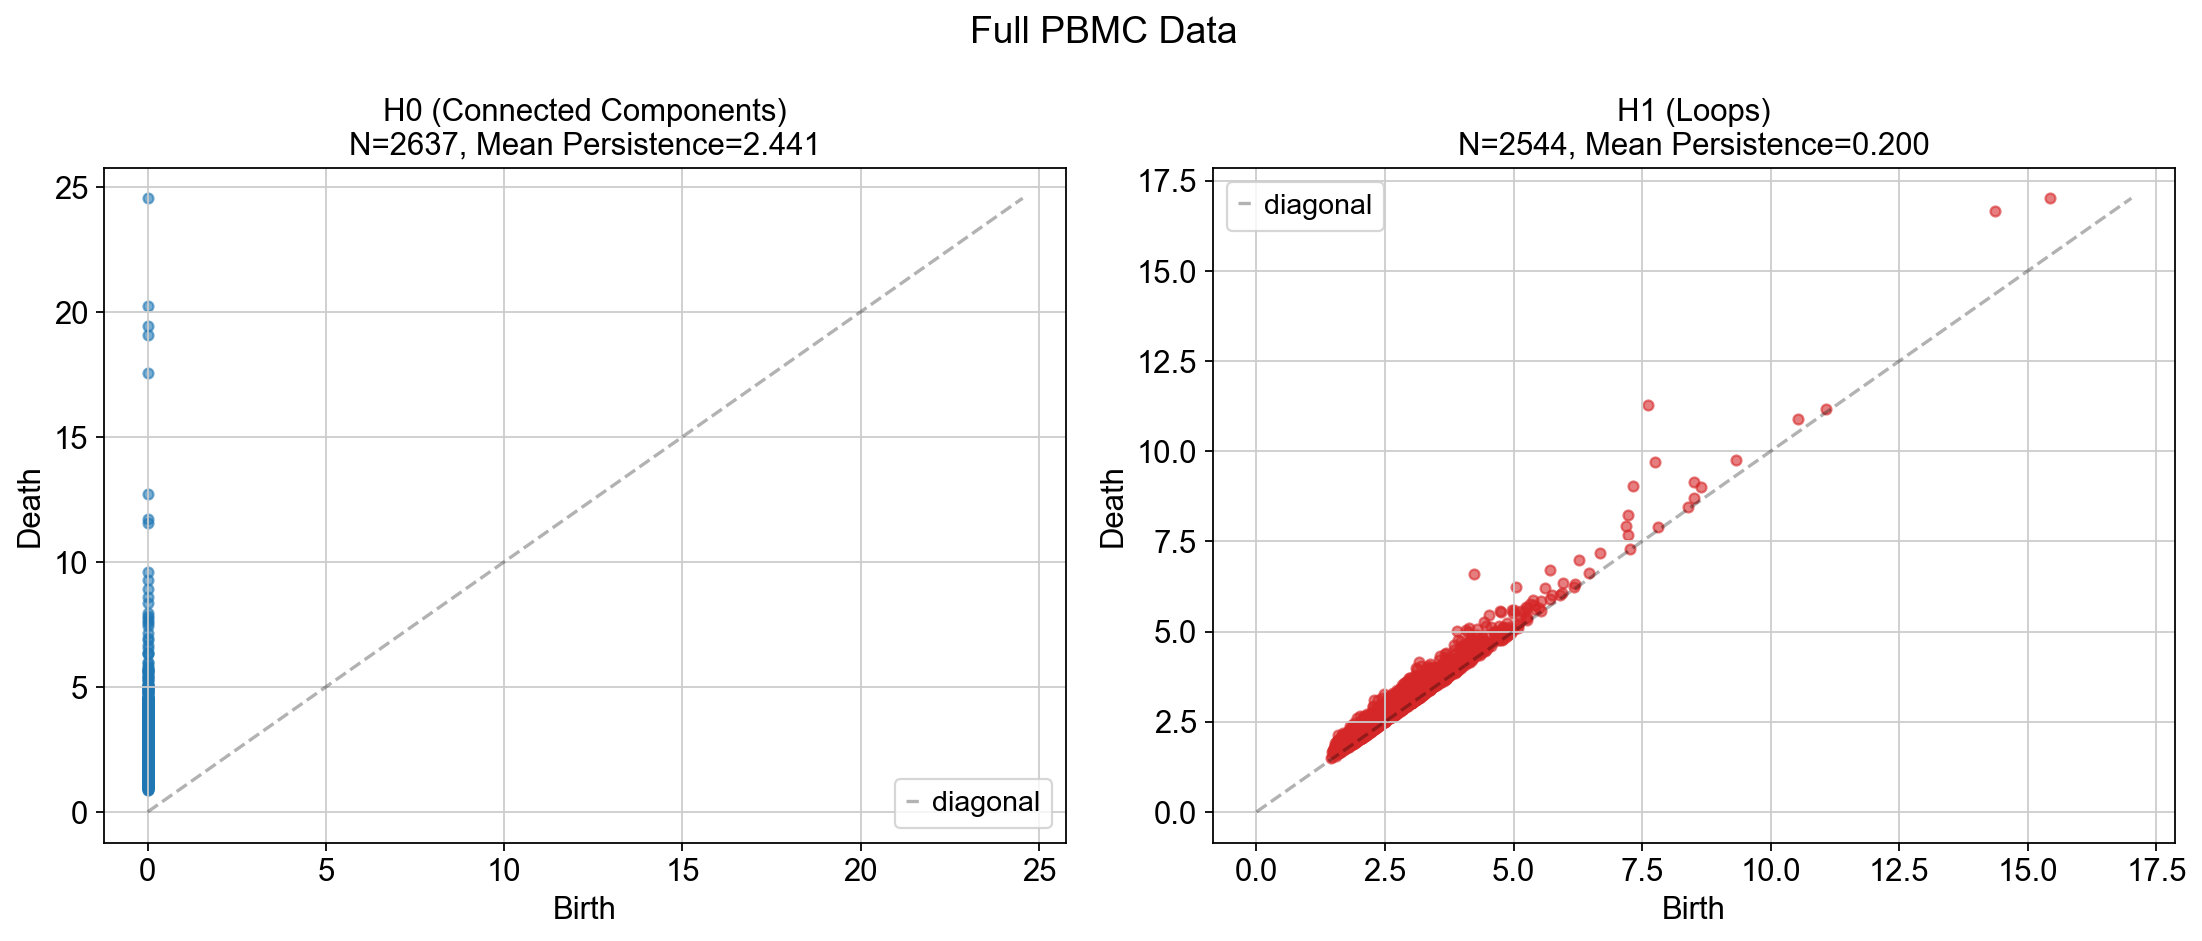

In [9]:
# 绘制持久图
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_persistence_diagrams(result_full["dgms"], ax=axes, title="Full PBMC Data")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "02_persistence_full.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# 提取统计特征
stats_full = extract_topological_stats(result_full["dgms"])
print("\n全量数据拓扑统计:")
for k, v in stats_full.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")


全量数据拓扑统计:
  n_h0: 2637
  n_h1: 2544
  mean_persistence_h0: 2.4407
  mean_persistence_h1: 0.2000


### 解读 H0（连通分支

H0 的每个点代表一个连通分支的"出生"和"死亡"距离。
 - **出生距离小** = 在很小的阈值下就与其他细胞连接
 - **死亡距离大** = 直到很大阈值才与其他细胞合并
 - **持久性高**（远离对角线）= 一个稳定的、独立的细胞群
  
如果 Leiden 聚类有效，我们应该看到：
 - 少量**高持久性**的 H0 特征（对应主要细胞亚群）
 - 大量**低持久性**的 H0 特征（噪声或过渡态细胞）

## 6. 拓扑验证 —— 各 Cluster 的持久同调对比

对每个 Leiden 簇分别计算持久同调，观察其内部拓扑结构。

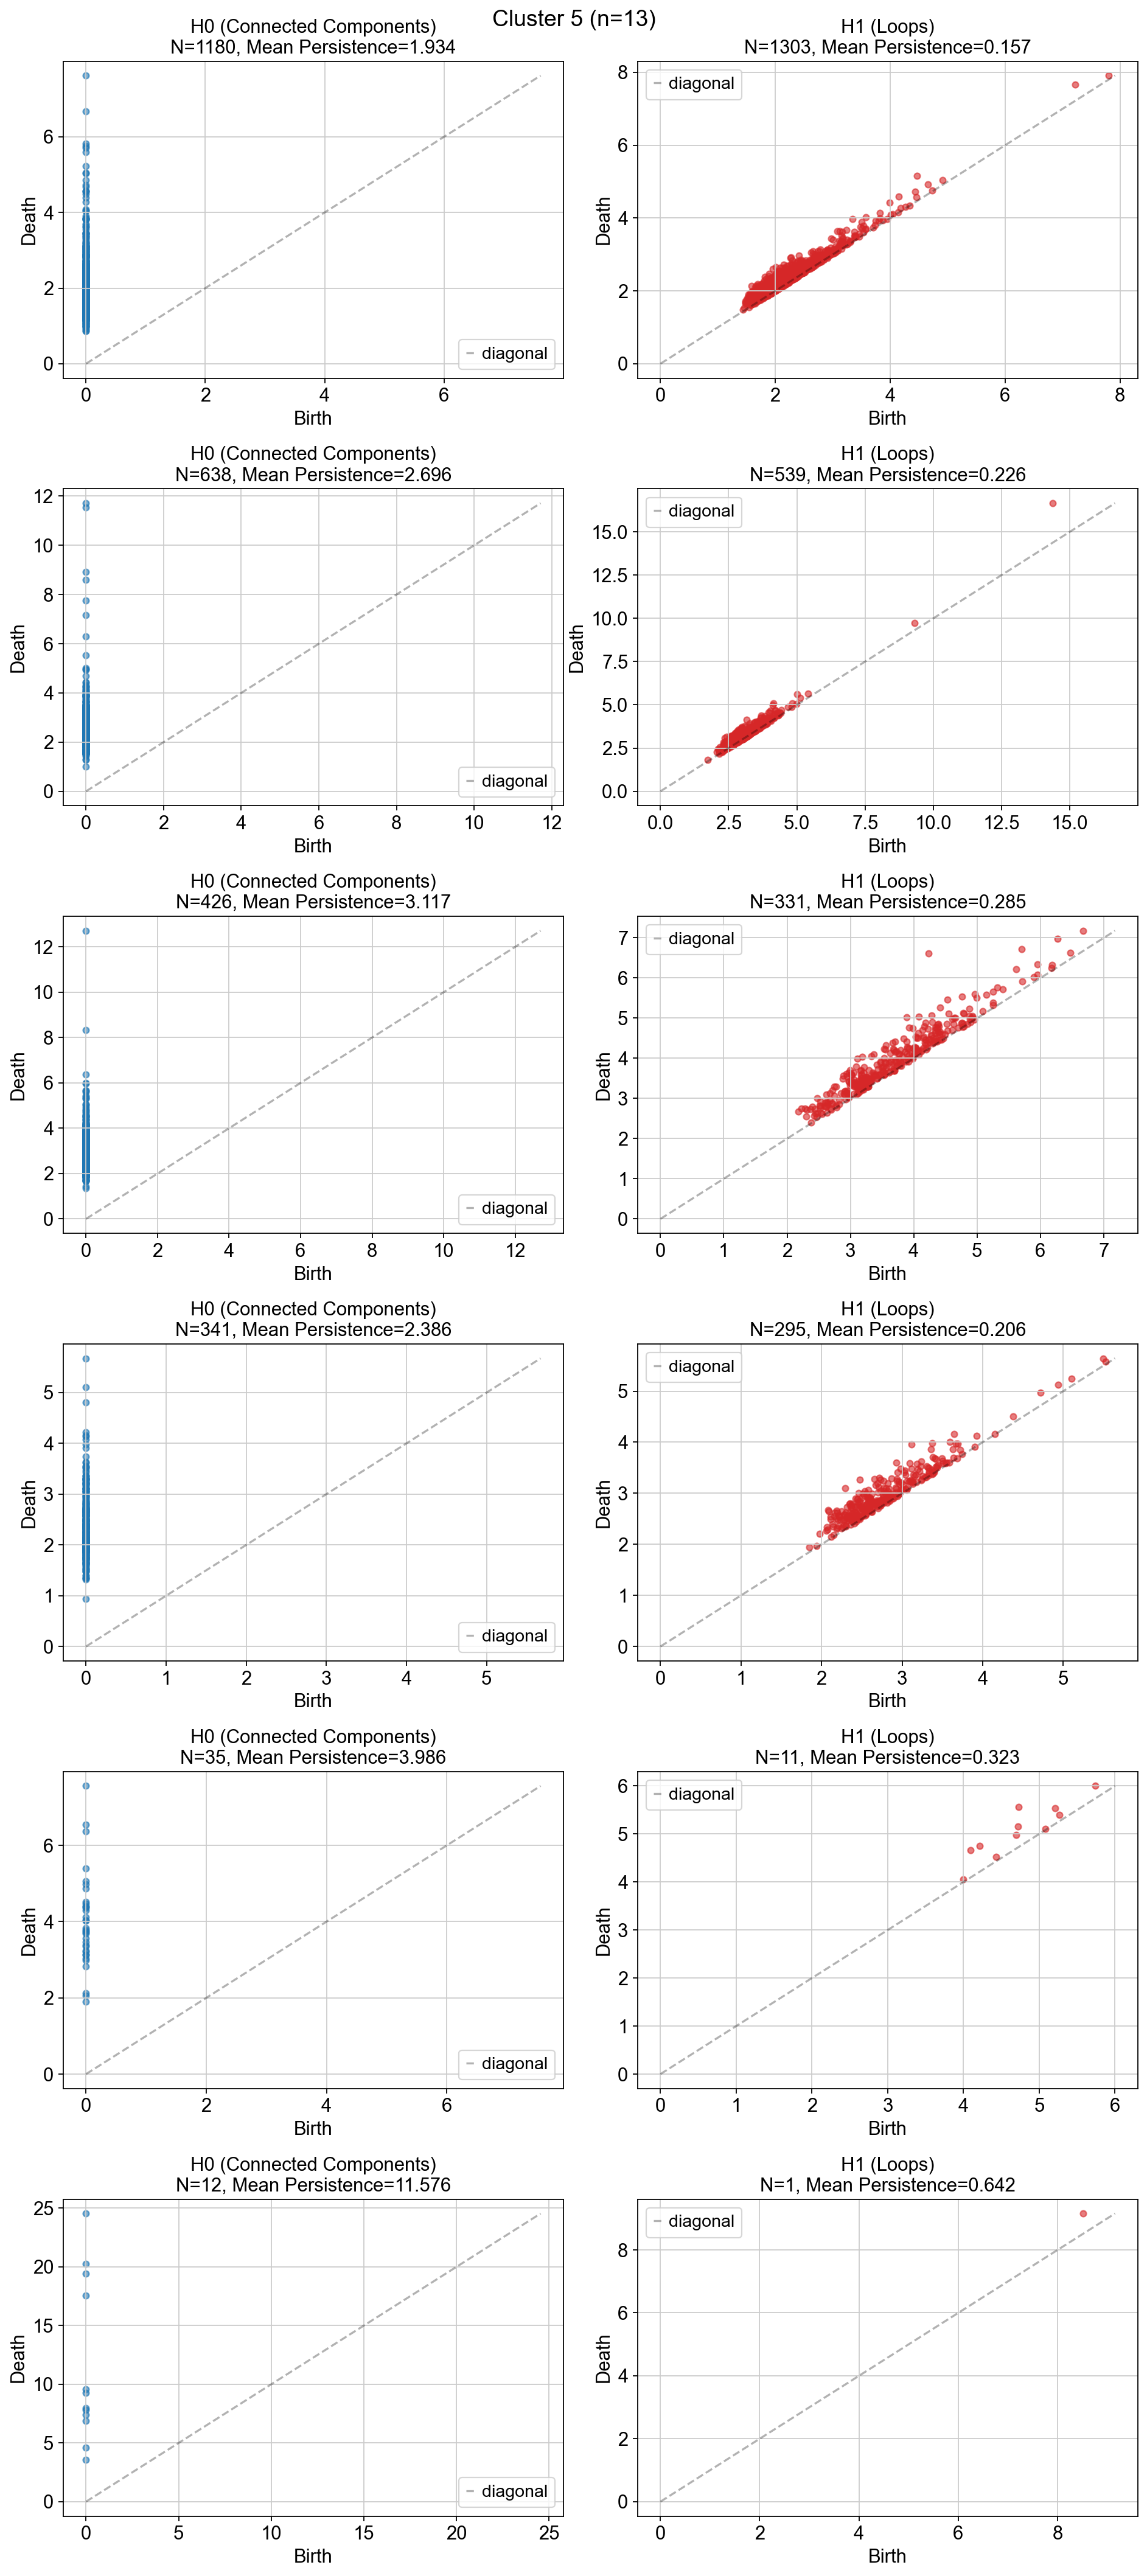

In [11]:
cluster_ids = adata.obs["leiden"].cat.categories
cluster_stats = []

fig, axes = plt.subplots(len(cluster_ids), 2, figsize=(12, 4.5 * len(cluster_ids)))

for i, cid in enumerate(cluster_ids):
    mask = adata.obs["leiden"] == cid
    coords = adata.obsm["X_pca"][mask, :config.TOPO_PCS]
    
    # 计算该簇的持久同调
    res = compute_persistence(coords, maxdim=config.TOPO_MAXDIM)
    stats = extract_topological_stats(res["dgms"])
    stats["cluster"] = cid
    stats["n_cells"] = mask.sum()
    cluster_stats.append(stats)
    
    # 绘制
    plot_persistence_diagrams(res["dgms"], ax=axes[i], 
                               title=f"Cluster {cid} (n={mask.sum()})")

plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "02_persistence_by_cluster.png", dpi=150, bbox_inches="tight")
plt.show()


In [12]:
# 汇总表格
df_stats = pd.DataFrame(cluster_stats)
print("\n各簇拓扑统计汇总:")
print(df_stats.to_string(index=False))


各簇拓扑统计汇总:
 n_h0  n_h1  mean_persistence_h0  mean_persistence_h1 cluster  n_cells
 1180  1303             1.934010             0.157091       0     1181
  638   539             2.695613             0.226156       1      639
  426   331             3.116785             0.285229       2      427
  341   295             2.385915             0.206237       3      342
   35    11             3.986361             0.322799       4       36
   12     1            11.575632             0.642049       5       13


In [13]:
# 保存
df_stats.to_csv(config.TABLES_DIR / "02_cluster_topology_stats.csv", index=False)

## 7. 关联分析：拓扑持久性 vs 聚类独立性

一个稳定的细胞亚群应该表现为：
 - 内部 H0 平均持久性低（簇内细胞紧密连接）
 - 外部 H0 持久性高（与其他簇边界清晰）

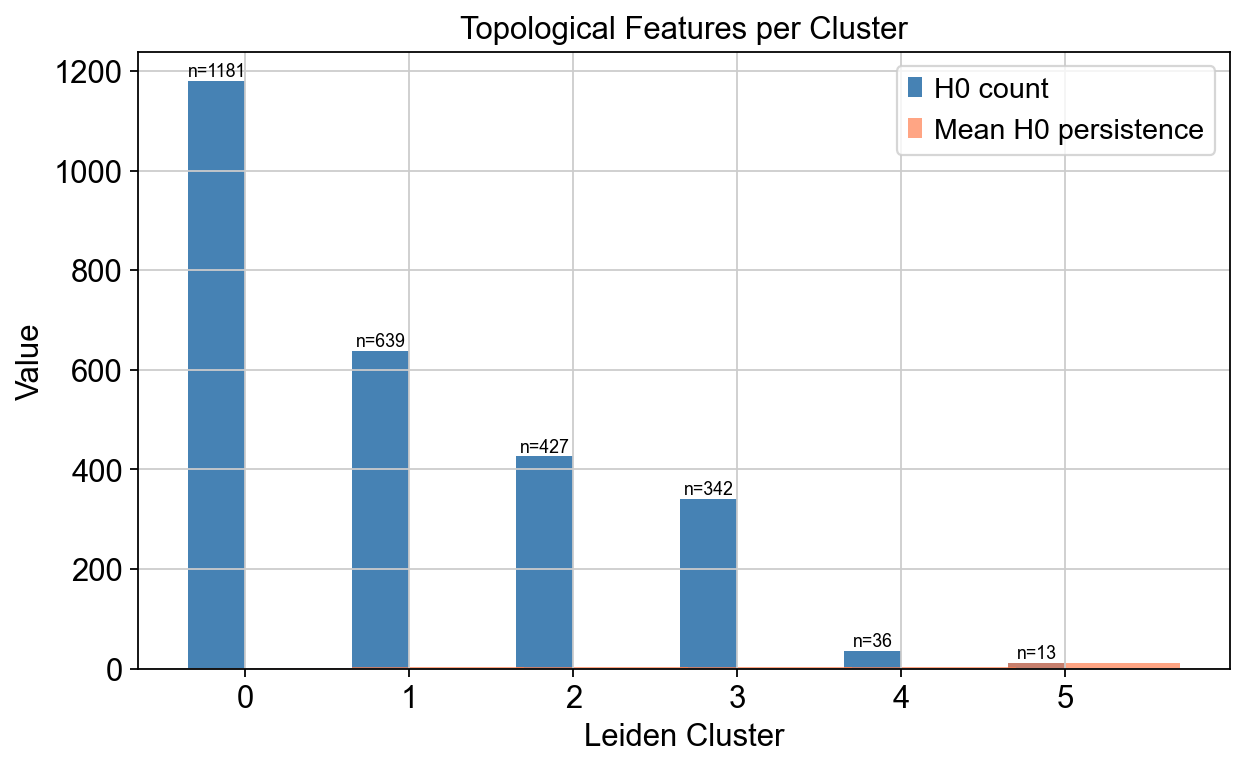

In [14]:
# 计算每个簇的"内部连接度"指标
# 用 H0 特征数量间接反映：特征越少，说明簇内越像一个连通整体

fig, ax = plt.subplots(figsize=(8, 5))
x = df_stats["cluster"].astype(str)
width = 0.35
x_pos = np.arange(len(x))

bars1 = ax.bar(x_pos - width/2, df_stats["n_h0"], width, label="H0 count", color="steelblue")
bars2 = ax.bar(x_pos + width/2, df_stats["mean_persistence_h0"], width*3, 
               label="Mean H0 persistence", color="coral", alpha=0.7)

ax.set_xlabel("Leiden Cluster")
ax.set_ylabel("Value")
ax.set_title("Topological Features per Cluster")
ax.set_xticks(x_pos)
ax.set_xticklabels(x)
ax.legend()

# 标注细胞数
for i, (bar, n) in enumerate(zip(bars1, df_stats["n_cells"])):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f"n={n}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "02_topology_cluster_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. 保存带聚类标签的数据

In [15]:
from src.io import save_h5ad
save_h5ad(adata, "pbmc3k_clustered.h5ad")
print("数据已保存，包含 leiden 标签和 UMAP 坐标")

数据已保存，包含 leiden 标签和 UMAP 坐标
